In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency

In [2]:
df = pd.read_csv("../data/Impact of Lifestyle Factors on Student Productivity (Responses).csv")

--- Inferential Statistics: Chi-Square Results ---
    Lifestyle Variable  Chi-Square Value  p-value Significant (p < 0.05)
     Daily Sleep Hours             16.71   0.0333                    Yes
   Junk Food Frequency              5.05   0.5380                     No
Physical Exercise Days              4.60   0.5964                     No
          Water Intake              8.76   0.1873                     No


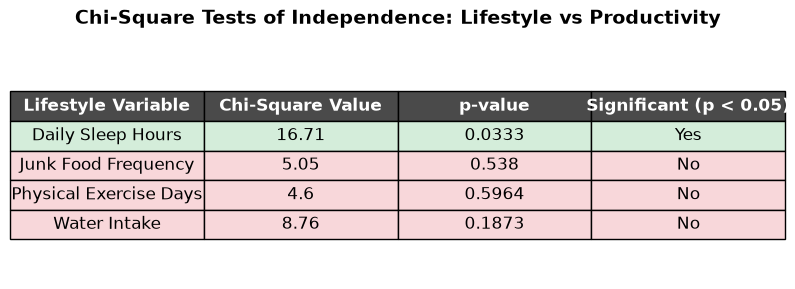

In [3]:



target_col = 'Q31. How would you rate your overall academic productivity on a typical day?'
df = df.dropna(subset=[target_col])

# Map target to 3 clear classes
def map_target(val):
    if val in [1.0, 2.0]: return 'Decreased'
    elif val == 3.0: return 'No impact'
    elif val in [4.0, 5.0]: return 'Increased'
    return 'No impact'

df['Target'] = df[target_col].apply(map_target)

# 2. Define Variables for Chi-Square Testing
chi_vars = [
    ('Q6. On average, how many hours do you sleep per night on weekdays?', 'Daily Sleep Hours'),
    ('Q17. How often do you consume fast food or processed junk food?', 'Junk Food Frequency'),
    ('Q11. How many days per week do you engage in deliberate physical exercise?', 'Physical Exercise Days'),
    ('Q18. How much water do you drink on a typical day?', 'Water Intake')
]

# 3. Perform Chi-Square Tests
chi_results = []
for col, name in chi_vars:
    contingency_table = pd.crosstab(df[col], df['Target'])
    chi2, p, dof, ex = chi2_contingency(contingency_table)
    
    chi_results.append({
        'Lifestyle Variable': name,
        'Chi-Square Value': round(chi2, 2),
        'p-value': round(p, 4),
        'Significant (p < 0.05)': 'Yes' if p < 0.05 else 'No'
    })

# Convert to DataFrame
chi_df = pd.DataFrame(chi_results)
print("--- Inferential Statistics: Chi-Square Results ---")
print(chi_df.to_string(index=False))


# 4. Generate a Visual Table for the Report
fig, ax = plt.subplots(figsize=(8, 3))
ax.axis('tight')
ax.axis('off')

# Color coding: Highlight the significant row
cell_colors = [['#f9f9f9']*4 for _ in range(len(chi_df))]
for i in range(len(chi_df)):
    if chi_df['Significant (p < 0.05)'][i] == 'Yes':
        cell_colors[i] = ['#d4edda']*4 # Light green for significant
    else:
         cell_colors[i] = ['#f8d7da']*4 # Light red for non-significant

table = ax.table(cellText=chi_df.values,
                 colLabels=chi_df.columns,
                 cellColours=cell_colors,
                 loc='center',
                 cellLoc='center')

table.auto_set_font_size(False)
table.set_fontsize(12)
table.scale(1.2, 1.8)

# Style the headers
for i in range(len(chi_df.columns)):
    cell = table[0, i]
    cell.set_text_props(weight='bold', color='white')
    cell.set_facecolor('#4a4a4a')

plt.title('Chi-Square Tests of Independence: Lifestyle vs Productivity', fontsize=14, pad=20, weight='bold')
plt.tight_layout()
plt.show()